In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from utility import *
from tools import *
from maps import *
from identify import *
from scipy.stats import linregress
from scipy.ndimage import maximum_filter, binary_dilation
from scipy.spatial.distance import cdist
from scipy.signal import detrend
from scipy.stats import pearsonr
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [ ]:
# Load the Data's directory.
# datadir = 'D:/Lab_Data/PV-Analysis/26-06-21(Mixed)/03_01_02.zda'
# datadir = 'D:/Lab_Data/Sst-Analysis/26-07-10(Mixed)/04_01_04.zda'
datadir = 'D:/Lab_Data/PV-Analysis/26-04-27/03_01_05.zda'

# Load the Tool Packages.
dataLoader = DataLoader(datadir)
tools = Tools()
maps = Maps()
identify = Identify()

In [3]:
# Parameters setting up.
timeline = np.linspace(0, 499.5, 1000)
stimulus = 200
basePt = 194
skipPt = 46
startPt = 200
numPt = 40

In [4]:
# Data Preprocessing.
Data = dataLoader.get_data()
Data = tools.Polynomial(startPt=basePt, numPt=skipPt, Data=Data)
Rli = dataLoader.get_rli()
Data = tools.Rli_Division(Rli=Rli, Data=Data)
Data = tools.T_filter(Data=Data)
Data = tools.S_filter(sigma=1, Data=Data)
Data_ave = np.mean(Data, axis=0)

# SNR Map. (Without Normalization)
snr_map = maps.SNR_Map(startPt=startPt, numPt=numPt, Data=Data)

# Max Amp Max. (Without Normalization)
max_amp_map = maps.Max_Amp_Map(startPt=startPt, numPt=numPt, Data=Data)

# Rli Map.
rli_high = np.array(Rli['rli_high'])
rli_low = np.array(Rli['rli_low'])

rli = ((rli_high - rli_low) / 3276.8)
bad = np.where(rli==0)
for coor in bad:
    rli[coor] = 0
rli = rli.reshape(80, 80)

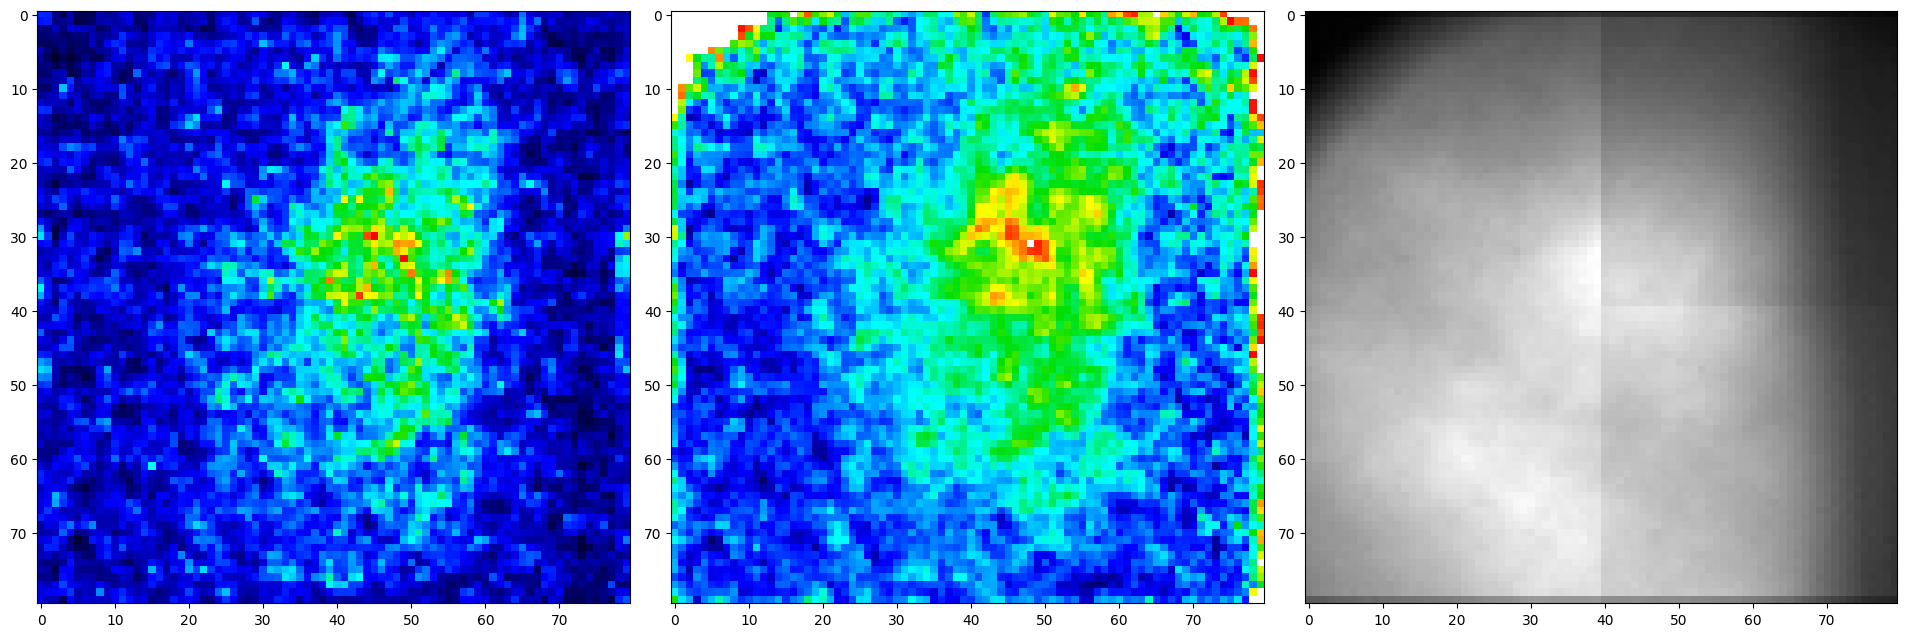

In [5]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 8))

ax1 = plt.subplot(1, 3, 1)
ax1.imshow(snr_map / np.max(snr_map), vmin=0, vmax=1, cmap=maps.colorbar())
# ax1.axis('off')

ax2 = plt.subplot(1, 3, 2)
ax2.imshow(max_amp_map, vmin=0, vmax=0.01, cmap=maps.colorbar())
# ax2.axis('off')

ax3 = plt.subplot(1, 3, 3)
ax3.imshow(rli, cmap='gray')
# ax3.axis('off')

fig.subplots_adjust(wspace=0.07)

plt.show()

In [6]:
# Stimulation Site.
# evoke = np.array([41, 34])
# evoke = np.array([60, 34])
# evoke = np.array([56, 16])
# evoke = np.array([62, 38])
# evoke = np.array([43, 34])
evoke = np.array([54, 39])

In [7]:
# Single Cell Identification.
candidates = identify.candidates(Data_ave=Data_ave, cutoff=99, startPt=startPt, numPt=numPt)
candidates = identify.select_non_overlap(candidates=candidates, snr_map=snr_map)
candidates = sorted(candidates, key=lambda x: (x[0], x[1]))

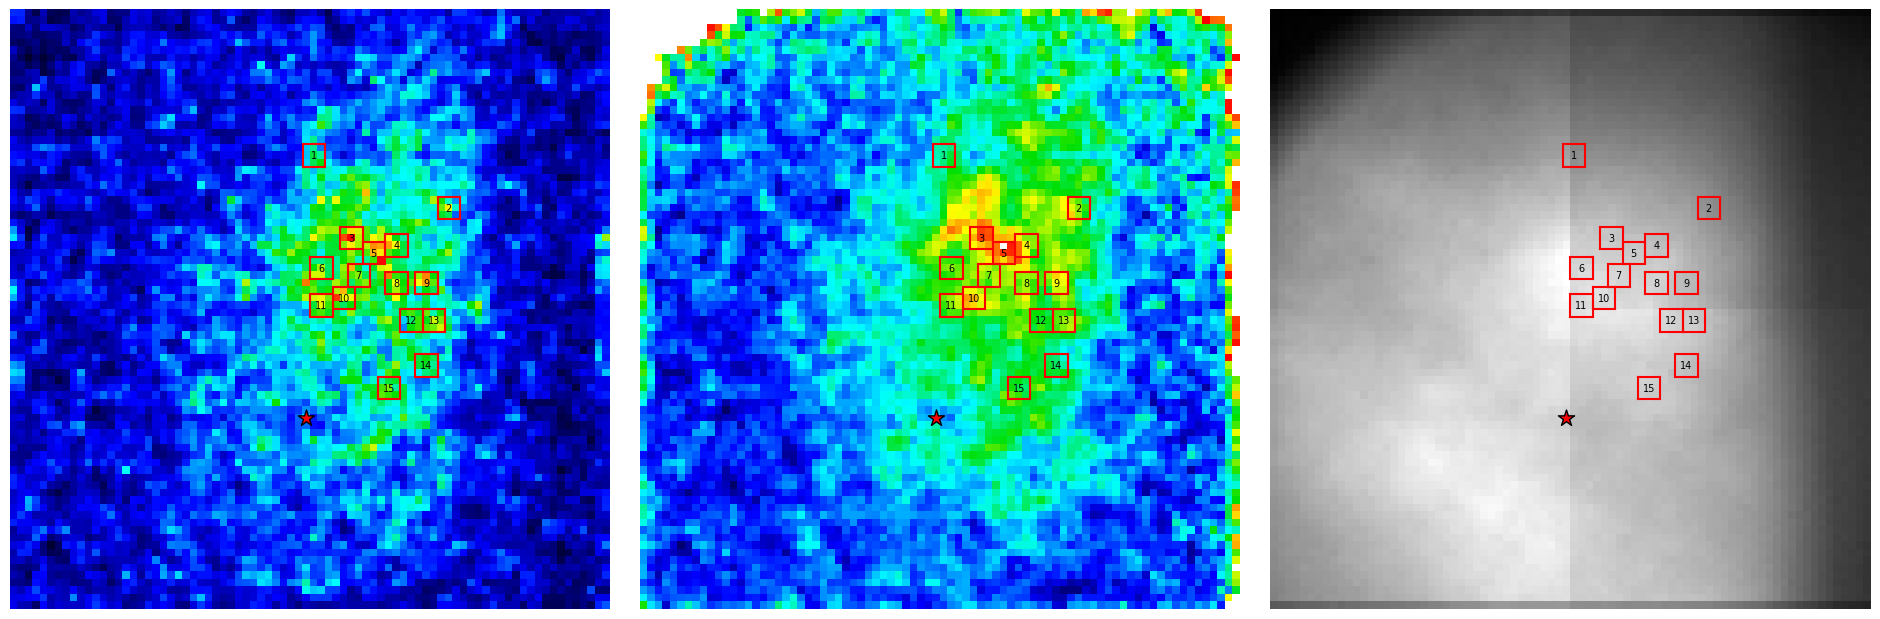

In [8]:
color = 'red'
linewidth = 1.5
index = np.array([[x[0], x[1]] for x in candidates])

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24,8))

ax1.imshow(snr_map / np.max(snr_map), vmin=0, vmax=1, cmap=maps.colorbar())
ax1.scatter(evoke[1], evoke[0], color='red', edgecolor='black', s=150, marker='*')

for i, coor in enumerate(index):

    #  Coordinates for columns and rows.   
    c = coor[0]
    r = coor[1]

    # Pixel boundaries.
    left   = c - 1.5
    right  = c + 1.5
    top    = r - 1.5
    bottom = r + 1.5

    # Draw square contour.
    ax1.plot([top, top], [left, right], color=color, linewidth=linewidth)
    ax1.plot([bottom, bottom], [left, right], color=color, linewidth=linewidth)
    ax1.plot([top, bottom], [left, left], color=color, linewidth=linewidth)
    ax1.plot([top, bottom], [right, right], color=color, linewidth=linewidth)

    # Label index.
    ax1.annotate(str(i+1), xy=(r, c), ha='center', va='center', fontsize=7, color='black')
    
    ax1.axis('off')

ax2.imshow(max_amp_map, vmin=0, vmax=0.01, cmap=maps.colorbar())
ax2.scatter(evoke[1], evoke[0], color='red', edgecolor='black', s=150, marker='*')

for i, coor in enumerate(index):

    #  Coordinates for columns and rows.   
    c = coor[0]
    r = coor[1]

    # Pixel boundaries.
    left   = c - 1.5
    right  = c + 1.5
    top    = r - 1.5
    bottom = r + 1.5
    
    # Draw square contour.
    ax2.plot([top, top], [left, right], color=color, linewidth=linewidth)
    ax2.plot([bottom, bottom], [left, right], color=color, linewidth=linewidth)
    ax2.plot([top, bottom], [left, left], color=color, linewidth=linewidth)
    ax2.plot([top, bottom], [right, right], color=color, linewidth=linewidth)

    # Label index.
    ax2.annotate(str(i+1), xy=(r, c), ha='center', va='center', fontsize=7, color='black')
    
    ax2.axis('off')
    
ax3.imshow(rli, cmap='gray')
ax3.scatter(evoke[1], evoke[0], color='red', edgecolor='black', s=150, marker='*')

for i, coor in enumerate(index):

    #  Coordinates for columns and rows.   
    c = coor[0]
    r = coor[1]

    # Pixel boundaries.
    left   = c - 1.5
    right  = c + 1.5
    top    = r - 1.5
    bottom = r + 1.5
    
    # Draw square contour.
    ax3.plot([top, top], [left, right], color=color, linewidth=linewidth)
    ax3.plot([bottom, bottom], [left, right], color=color, linewidth=linewidth)
    ax3.plot([top, bottom], [left, left], color=color, linewidth=linewidth)
    ax3.plot([top, bottom], [right, right], color=color, linewidth=linewidth)

    # Label index.
    ax3.annotate(str(i+1), xy=(r, c), ha='center', va='center', fontsize=7, color='black')
    
    ax3.axis('off')

fig.subplots_adjust(wspace=0.05)

plt.show()

In [9]:
n_cells = len(candidates)

cell_trace = np.empty((n_cells, Data.shape[3]))
cell_amp = np.empty(n_cells)
cell_dist = np.empty(n_cells)

for i, candidate in enumerate(candidates):

    coords = np.asarray(candidate[3])

    trace = Data_ave[coords[:, 0], coords[:, 1], :].mean(axis=0)

    cell_trace[i] = trace

    cell_amp[i] = np.max(trace[startPt:startPt + numPt])

    cell_dist[i] = (np.hypot(candidate[0] - evoke[0], candidate[1] - evoke[1]) * 3)
    
# Pearson correlation
r, p = pearsonr(cell_dist, cell_amp)

# Linear regression
result = linregress(cell_dist, cell_amp)

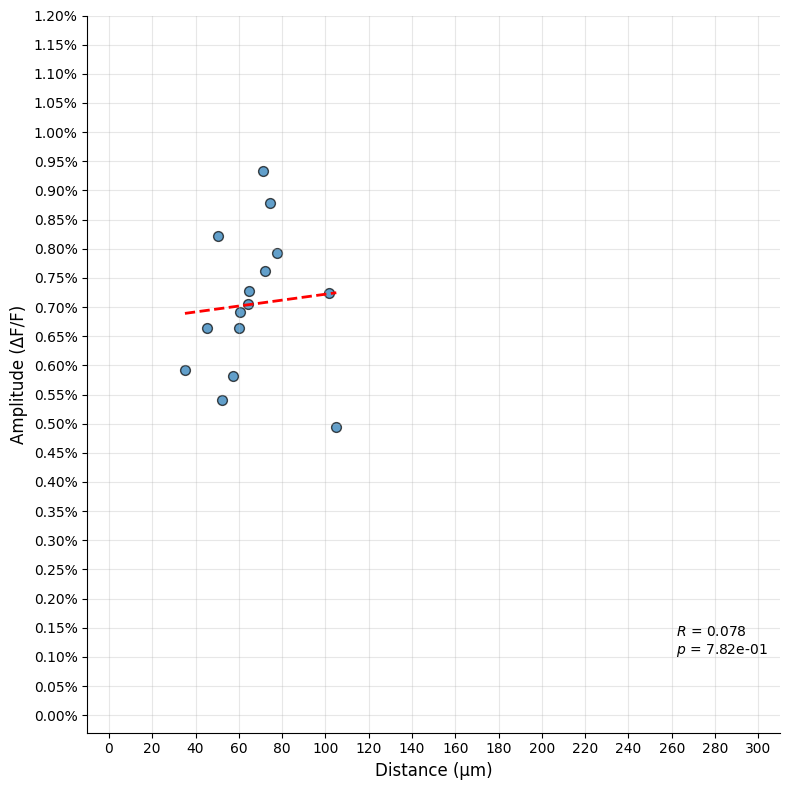

In [10]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(cell_dist, cell_amp, color='tab:blue', edgecolors='black', s=50, alpha=0.7)

# Remove top/right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Labels
ax.set_xlabel('Distance (μm)', fontsize=12)
ax.set_ylabel('Amplitude (ΔF/F)', fontsize=12)

# Linear regression line
x = np.linspace(cell_dist.min(), cell_dist.max(), 200)
y = result.slope * x + result.intercept

ax.plot(x, y, color='red', linewidth=2, linestyle='--')

ax.text(0.85, 0.15, f'$R$ = {result.rvalue:.3f}\n$p$ = {result.pvalue:.2e}', transform=ax.transAxes, ha='left', va='top', fontsize=10)

# Axis
ax.set_ylim(-0.0003, 0.012)
ax.set_xlim(-10, 310)

# Tick labels
yticks = np.arange(0, 0.0121, 0.0005)
ax.set_yticks(yticks)
ax.set_yticklabels([f'{y:.2%}' for y in yticks], fontsize=10)

xticks = np.arange(0, 310, 20)
ax.set_xticks(xticks)
ax.set_xticklabels([f'{y}' for y in xticks], fontsize=10)

ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(10, 2, figsize=(16, 2.5 * 10))
fig.subplots_adjust(wspace=0.2)

for i in range(20):
    if i <= 18:
        row = i % 10
        col = i // 10
        ax = axes[row, col]
    
        ax.plot(timeline, cell_trace[i], color='black', linewidth=2)
        ax.axvline(x=stimulus/2, color='black', linewidth=1, linestyle='--')
        # ax.axvline(x=(stimulus+numPt)/2, color='black', linewidth=1, linestyle='--')
        ax.axvspan(startPt/2, (startPt+numPt)/2, color='gray', alpha=0.3)
        ax.axhline(y=0, color='black', linewidth=1)
        ax.text(0.02, 0.9, f'{i+1}', transform=ax.transAxes, fontsize=15, va='top')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_ylim(-0.01, 0.015)
        ax.set_xlim((60, 210))

        x0 = 150
        y0 = 0.012
        dx = 10
        dy = 0.002
        
        # Horizontal scale bar
        ax.plot([x0, x0 + dx], [y0, y0], color='black', linewidth=2)

        # Vertical scale bar
        ax.plot([x0, x0], [y0, y0 + dy], color='black', linewidth=2)

        # Labels
        ax.text(x0, y0 - 0.0025, '10 ms', va='bottom', fontsize=10)
        ax.text(x0 - 3, y0, '0.2% ΔF/F', ha='right', fontsize=10)
        ax.text(0.95, 0.85, f'Amplitude: {np.max(cell_trace[i][startPt: startPt+numPt])*100:.2f}%', 
                transform=ax.transAxes, ha='right', va='top', fontsize=10)
        
    else:
        row = i % 10
        col = i // 10
        ax = axes[row, col]
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_ylim((-0.002, 0.012))
        ax.set_xlim((0, 300))
        
plt.show()

In [ ]:
num = len(index)
trial = Data.shape[0]
latency = np.zeros((num, trial))
trace = np.zeros((num, trial, len(timeline)))

for i in range(num):
    for j in range(trial):
        
        data_tem = []
        for coor in candidates[i][3]:
            data_tem.append(Data[j, coor[0], coor[1], :])
        data_tem = np.array(data_tem)
        Trace = np.mean(data_tem, axis=0)
        trace[i][j] = Trace
        latency[i][j] = maps.Half_Amp_Latency_3(Trace=Trace, startPt=startPt, numPt=numPt)

In [ ]:
num = len(index)
trial = Data.shape[0]
count = 0

plt.subplots(1, 2, figsize=(16,8))
ax1 = plt.subplot(1, 2, 1)
ax2 = plt.subplot(1, 2, 2)
ax1.imshow(snr_map / np.max(snr_map), vmin=0, vmax=1, cmap=maps.colorbar())
ax1.scatter(evoke[1], evoke[0], color='red', edgecolor='black', s=150, marker='*')
ax2.imshow(rli, cmap='gray')
ax2.scatter(evoke[1], evoke[0], color='red', edgecolor='black', s=150, marker='*')

for i, coor in enumerate(index):

    #  Coordinates for columns and rows.   
    c = coor[0]
    r = coor[1]

    # Pixel boundaries.
    left   = c - 1.5
    right  = c + 1.5
    top    = r - 1.5
    bottom = r + 1.5

    # Draw square contour.
    ax1.plot([top, top], [left, right], color=color, linewidth=linewidth)
    ax1.plot([bottom, bottom], [left, right], color=color, linewidth=linewidth)
    ax1.plot([top, bottom], [left, left], color=color, linewidth=linewidth)
    ax1.plot([top, bottom], [right, right], color=color, linewidth=linewidth)

    ax2.plot([top, top], [left, right], color=color, linewidth=linewidth)
    ax2.plot([bottom, bottom], [left, right], color=color, linewidth=linewidth)
    ax2.plot([top, bottom], [left, left], color=color, linewidth=linewidth)
    ax2.plot([top, bottom], [right, right], color=color, linewidth=linewidth)

    # Label index.
    ax1.annotate(str(i+1), xy=(r, c), ha='center', va='center', fontsize=7, color='black')
    ax2.annotate(str(i+1), xy=(r, c), ha='center', va='center', fontsize=7, color='black')

for i in range(num-1):
    for j in range(i+1, num):
        
        dist = np.sqrt((index[i][0] - index[j][0])**2 + (index[i][1] - index[j][1])**2) * 6
        Slope, _, _, pValue, _ = linregress(latency[i], latency[j])
        if pValue <=0.05 and Slope > 0:
            count = count + 1
            print('Neuron', i+1, 'and Neuron', j+1, 'are active and correlated with a positive slope, and the P-Value is:', 
                  np.round(pValue, 6), ', distance is:', dist, 'um.')
            loc_1 = index[i]
            loc_2 = index[j]
            ax1.plot([loc_1[1], loc_2[1]], [loc_1[0], loc_2[0]], color='red', linewidth=1)
            ax2.plot([loc_1[1], loc_2[1]], [loc_1[0], loc_2[0]], color='red', linewidth=1)

plt.show()

print(count, 'pairs are correlated.')
print('Totally', int(num*(num-1)/2), 'pairs.')

In [ ]:
cell_1 = 5
cell_2 = 18

fig, axes = plt.subplots(10, 2, figsize=(16, 2.5 * 10))

for i in range(20):
    if i < 20:
        row = i % 10
        col = i // 10
        ax = axes[row, col]
    
        ax.plot(timeline, trace[cell_1-1][i], color='black', linewidth=2)
        ax.plot(timeline, trace[cell_2-1][i], color='red', alpha=0.7, linewidth=2)
        ax.axvline(x=stimulus/2, color='black', linewidth=1, linestyle='--')
        # ax.axvline(x=(stimulus+numPt)/2, color='black', linewidth=1, linestyle='--')
        ax.axvspan(startPt/2, (startPt+numPt)/2, color='gray', alpha=0.3)
        ax.axhline(y=0, color='black', linewidth=1)
        ax.text(0.02, 0.9, f'{i+1}', transform=ax.transAxes, fontsize=15, va='top')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_ylim(-0.01, 0.015)
        ax.set_xlim((60, 210))

        x0 = 150
        y0 = 0.012
        dx = 10
        dy = 0.002
        
        # Horizontal scale bar
        ax.plot([x0, x0 + dx], [y0, y0], color='black', linewidth=2)

        # Vertical scale bar
        ax.plot([x0, x0], [y0, y0 + dy], color='black', linewidth=2)

        # Labels
        ax.text(x0, y0 - 0.004, '10 ms', va='bottom', fontsize=10)
        ax.text(x0 - 1, y0, '0.2% ΔF/F', ha='right', fontsize=10)
        ax.text(x0 + 25, y0+0.004, f'Latency of Cell #{cell_1}: {latency[cell_1-1][i] - startPt/2:.2f}ms', 
                va='center', ha='left', fontsize=10)
        ax.text(x0 + 25, y0, f'Latency of Cell #{cell_2}: {latency[cell_2-1][i] - startPt/2:.2f}ms', 
                va='center', ha='left', fontsize=10)
    else:
        ax = axes[4, 1]
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_ylim((-0.002, 0.012))
        ax.set_xlim((0, 300))
        
plt.show()

In [ ]:
# DATA
cell_1 = 5
cell_2 = 18
cell_count_half = []
cell_count_peak = []

for i in range(trace.shape[1]):
    cell_count_half.append(latency[cell_2-1][i] - latency[cell_1-1][i])

for i in range(trace.shape[1]):
    peak_idx1 = np.argmax(trace[cell_1-1][i][startPt:startPt+numPt]) + startPt
    peak_idx1 = peak_idx1 / 2
    peak_idx2 = np.argmax(trace[cell_2-1][i][startPt:startPt+numPt]) + startPt
    peak_idx2 = peak_idx2 / 2
    cell_count_peak.append(peak_idx2 - peak_idx1)
    
cell_count_half = np.array(cell_count_half)
cell_count_peak = np.array(cell_count_peak)

# Histogram
fig, ax = plt.subplots(figsize=(8, 6))

ax.hist(cell_count_half, range=(-9.5, 9.5), bins=19, histtype='step', edgecolor='black', linewidth=2, label='Half Amplitude Latency')
ax.hist(cell_count_peak, range=(-9.5, 9.5), bins=19, histtype='step', edgecolor='red', alpha=0.7, linewidth=2, label='Peak-to-Peak Latency')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticks(np.arange(-10, 10.5, 2))
ax.set_xticklabels([f'{x} ms' for x in np.arange(-10, 10.5, 2)], rotation=45)
ax.set_yticks(np.arange(0, 15.6, 1))
ax.set_yticklabels([f'{y}' for y in np.arange(0, 15.6, 1)], rotation=45)
ax.set_xlim(-10.6, 10.6)
ax.set_ylim(-1, 16)
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Spike Count')
ax.axvline(0, color='black', linewidth=1.2, linestyle='--')
ax.grid(axis='y', linestyle='--', linewidth=0.7, alpha=0.3)
ax.legend(loc='upper right', fontsize=10)

fig.tight_layout()
plt.show()

In [ ]:
# DATA
cell_1 = 5
cell_2 = 18
cell_count_1 = []
cell_count_2 = []

'''
for i in range(trace.shape[1]):
    cell_count_1.append(latency[cell_1-1][i] - startPt/2)
    cell_count_2.append(latency[cell_2-1][i] - startPt/2)

'''
for i in range(trace.shape[1]):
    peak_idx1 = np.argmax(trace[cell_1-1][i][startPt:startPt+numPt]) + startPt
    peak_idx1 = peak_idx1 / 2
    cell_count_1.append(peak_idx1 - startPt/2)
    peak_idx2 = np.argmax(trace[cell_2-1][i][startPt:startPt+numPt]) + startPt
    peak_idx2 = peak_idx2 / 2
    cell_count_2.append(peak_idx2 - startPt/2)


cell_count_1 = np.array(cell_count_1)
cell_count_2 = np.array(cell_count_2)

# Histogram
fig, ax = plt.subplots(figsize=(8, 6))

ax.hist(cell_count_1, range=(-0.5, 19.5), bins=20, histtype='step', edgecolor='black', linewidth=2, label=f'Cell #{cell_1}')
ax.hist(cell_count_2, range=(-0.5, 19.5), bins=20, histtype='step', edgecolor='red', alpha=0.7, linewidth=2, label=f'Cell #{cell_2}')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticks(np.arange(0, 19.5, 1.5))
ax.set_xticklabels([f'{x + startPt/2} ms' for x in np.arange(0, 19.5, 1.5)], rotation=45)
ax.set_yticks(np.arange(-1, 15.6, 1))
ax.set_yticklabels([f'{y}' for y in np.arange(-1, 15.6, 1)], rotation=45)
ax.set_xlim(-1.0, 20.0)
ax.set_ylim(-1, 16)
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Spike Count')
# ax.axvline(0, color='black', linewidth=1.2, linestyle='--')
# ax.grid(axis='y', linestyle='--', linewidth=0.7, alpha=0.3)
#ax.legend(loc='upper center', fontsize=10)

ax2 = ax.twinx()
ax2.set_ylabel('ΔF/F', rotation=270)
ax2.set_ylim(-0.001, 0.016)
ax2.set_yticks(np.arange(-0.001, 0.0156, 0.001))
# ax2.set_yticklabels([f'{y:.2%}' for y in np.arange(-0.001, 0.0156, 0.001)], rotation=45)
ax2.spines['top'].set_visible(False)
ax2.plot(timeline[0:numPt], cell_trace[cell_1-1][startPt:startPt+numPt], 
         color='black', alpha=0.7, linewidth=2, label=f'Cell #{cell_1} Trace', linestyle='--')
ax2.plot(timeline[0:numPt], cell_trace[cell_2-1][startPt:startPt+numPt], 
         color='red', alpha=0.7, linewidth=2, label=f'Cell #{cell_2} Trace', linestyle='--')

fig.legend(loc='upper center')
fig.tight_layout()
plt.show()

In [ ]:
# Cells' Number
cell_1 = 5
cell_2 = 18

# regression
x_data = latency[cell_1-1] - startPt/2
y_data = latency[cell_2-1] - startPt/2

slope, intercept, rvalue, pvalue, stderr = linregress(x_data, y_data)

x_fit = np.linspace(0, 24, 200)
y_fit = slope * x_fit + intercept

fig, ax = plt.subplots(figsize=(8, 8), dpi=100)

# SCATTER

ax.scatter(x_data, y_data, s=80, color='#4C72B0', alpha=0.75, edgecolor='black', linewidth=0.8)

# LINEAR FIT

ax.plot(x_fit, y_fit, color='#C44E52', linewidth=2.5, linestyle = '--', label='Linear fit')

# AXIS

# ax.set_xlim(-0.2, 22.6)
# ax.set_ylim(-0.2, 22.6)

ax.set_xticks(np.arange(0, 22.6, 2.0))
ax.set_yticks(np.arange(0, 22.6, 2.0))

ax.tick_params(labelsize=15)

ax.set_xlabel(f'Cell #{cell_1} latency (ms)', fontsize=20)

ax.set_ylabel(f'Cell #{cell_2} latency (ms)', fontsize=20)

# equal aspect
ax.set_aspect('equal')

# STATS BOX

stats_text = (f'$p$ = {pvalue:.2e}\n'f'Slope = {slope:.2f}')

ax.text(0.1, 0.9, stats_text, transform=ax.transAxes, fontsize=15, va='top', bbox=dict(facecolor='white', alpha=0.85, edgecolor='none'))

# STYLE

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

ax.legend(frameon=False, fontsize=20, loc='lower right')
ax.grid(linewidth=0.7, alpha=0.3)

# ax.set_title(f'Control condition', fontsize=20, pad=15)

plt.tight_layout()
plt.show()

In [ ]:
# DATA
cell_1 = 10
cell_2 = 17

trace1 = cell_trace[cell_1 - 1]
trace2 = cell_trace[cell_2 - 1]

fig, ax = plt.subplots(figsize=(15,5), dpi=300)
# ax.set_title('Latency Comparison between Cell #{} and Cell #{} (Add Blocker)'.format(cell_1, cell_2), fontsize=24, pad=20)

peak_idx1 = np.argmax(trace1[startPt:startPt+numPt])
peak_idx2 = np.argmax(trace2[startPt:startPt+numPt])

peak_t1 = timeline[peak_idx1] + startPt/2
peak_t2 = timeline[peak_idx2] + startPt/2

latency_diff = abs(peak_t2 - peak_t1)

# TRACES (main signal)
ax.plot(timeline, trace1, color='#4C72B0', linewidth=2.5, label='Cell #{}'.format(cell_1))

ax.plot(timeline, trace2, color='#C44E52', linewidth=2.5, label='Cell #{}'.format(cell_2))

# STIMULATION
stim_t = stimulus / 2

ax.axvline(stim_t, color='black', linestyle='--', linewidth=2, alpha=0.7)
ax.axvline(stim_t + numPt/2, color='black', linestyle='--', linewidth=2, alpha=0.7)
ax.axvspan(stim_t, stim_t + numPt/2, color='gray', alpha=0.3, label='Measure Window')

ax.text(stim_t - 7, max(trace1.max(), trace2.max()) * 0.85, 'Stim', fontsize=15)

# PEAK markers (subtle)
ax.axvline(peak_t1, color='#4C72B0', linestyle=':', linewidth=2, label='Peak of Cell #{}'.format(cell_1))
ax.axvline(peak_t2, color='#C44E52', linestyle=':', linewidth=2, label='Peak of Cell #{}'.format(cell_2))

# LATENCY BRACKET (main conclusion)
y_bar = max(trace1.max(), trace2.max()) * 1.05

ax.plot([peak_t1, peak_t2], [y_bar, y_bar], color='black', linewidth=2)

ax.plot([peak_t1, peak_t1], [y_bar*0.98, y_bar*1.02], color='black', linewidth=2)
ax.plot([peak_t2, peak_t2], [y_bar*0.98, y_bar*1.02], color='black', linewidth=2)

ax.text((peak_t1 + peak_t2)/2 + 10, y_bar * 1.03, f'Δt = {latency_diff:.1f} ms', ha='center', fontsize=16, fontweight='bold')

# SCALE BAR (NEW)

x0 = 75
y0 = min(trace1.max(), trace2.max()) * 0.8

dx = 10        # 10 ms
dy = 0.002     # ΔF/F scale

# horizontal (time)
ax.plot([x0, x0+dx], [y0, y0], color='black', linewidth=3)

# vertical (amplitude)
ax.plot([x0, x0], [y0, y0+dy], color='black', linewidth=3)

# labels
ax.text(x0 + dx/2, y0 - 0.0008, '10 ms', ha='center', fontsize=14)

ax.text(x0 - 3, y0 + dy/2, '0.2% ΔF/F', va='center', rotation=90, fontsize=14)

# AXIS STYLE
ax.set_xlim(55, 150)
ax.set_ylim(min(trace1.min(), trace2.min())*1.2, max(trace1.max(), trace2.max())*1.2)

ax.set_xlabel('Time (ms)', fontsize=20)
ax.set_ylabel('ΔF/F', fontsize=20)

ax.tick_params(labelsize=15)
ax.set_xticks(np.arange(60, 151, 10))

yticks = np.arange(0.0015 * (min(trace1.min(), trace2.min())//0.0015), max(trace1.max(), trace2.max())*1.2, 0.0015)
ax.set_yticks(yticks)
ax.set_yticklabels([f'{y:.2%}' for y in yticks], fontsize=15)

# SPINES (clean look)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

# LEGEND (clean)

ax.legend(frameon=False, fontsize=18, loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
'''
with open('C:/Users/Kevin/Desktop/26-02-17/02_01_06_latency.dat', 'a') as f:
    for coor in latency:
        line = '[' + ' '.join(map(str,coor)) + ']'
        f.write(line + '\n')

with open('C:/Users/Kevin/Desktop/26-02-17/02_01_06_location.dat', 'a') as f:
    for coor in index:
        line = '[' + ' '.join(map(str,coor)) + ']'
        f.write(line + '\n')

with open('C:/Users/Kevin/Desktop/26-02-17/02_01_06_rli.dat', 'a') as f:
    for coor in rli:
        line = '[' + ' '.join(map(str,coor)) + ']'
        f.write(line + '\n')
'''